<a href="https://colab.research.google.com/github/Bpatnaik470/Bpatnaik470/blob/main/Course_end_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import zipfile

zip_file_path = '/content/Dataset (12).zip'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print(f'Successfully unzipped {zip_file_path} to /content/')


Successfully unzipped /content/Dataset (12).zip to /content/


In [5]:
import os

# List the contents of the unzipped directory to find the actual data file
unzipped_contents = os.listdir('/content/')
print('Contents of /content/ after unzipping:')
for item in unzipped_contents:
    print(item)


Contents of /content/ after unzipping:
.config
Home_Loan_Dataset
Lending_Dataset
Dataset (12).zip
Lesson_09_Transfer_Learning
Lesson_03_Artificial_Neural_Network
Lesson_08_Convolutional_Neural_Network
Lesson_11_Recurrent_Neural_Networks
1688644938_project_home_loan_data_analysis (2).docx
Course_End_Project_Dataset (3).zip
CEP_Datasets
sample_data


In [6]:
import zipfile
import os

# Path to the user-selected zip file
selected_zip_file_path = '/content/Course_End_Project_Dataset (3).zip'

# Unzip the file
with zipfile.ZipFile(selected_zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print(f'Successfully unzipped {selected_zip_file_path} to /content/')

# List the contents of /content/ to find the extracted data file(s)
print('\nContents of /content/ after unzipping:')
for item in os.listdir('/content/'):
    print(item)


Successfully unzipped /content/Course_End_Project_Dataset (3).zip to /content/

Contents of /content/ after unzipping:
.config
Home_Loan_Dataset
Lending_Dataset
Dataset (12).zip
Lesson_09_Transfer_Learning
Lesson_03_Artificial_Neural_Network
Lesson_08_Convolutional_Neural_Network
Lesson_11_Recurrent_Neural_Networks
1688644938_project_home_loan_data_analysis (2).docx
Course_End_Project_Dataset (3).zip
CEP_Datasets
sample_data


In [11]:
import pandas as pd

df = pd.read_csv('/content/Home_Loan_Dataset/loan_data (1).csv')
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...  

In [12]:
print("\nNull values in the dataset:")
print(df.isnull().sum())


Null values in the dataset:
SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64


In [13]:
print("\nPercentage of default for TARGET column:")
default_percentage = df['TARGET'].value_counts(normalize=True) * 100
print(default_percentage)


Percentage of default for TARGET column:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import numpy as np

# Drop SK_ID_CURR as it's an identifier and not a feature
df_processed = df.drop('SK_ID_CURR', axis=1)

# Separate features (X) and target (y)
X = df_processed.drop('TARGET', axis=1)
y = df_processed['TARGET']

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")


Numerical columns: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUI

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline # Import Pipeline

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('num_imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('cat_imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough' # Keep other columns as they are (if any)
)

# Apply preprocessing to the features
X_preprocessed = preprocessor.fit_transform(X)

print("Shape of X after preprocessing:", X_preprocessed.shape)

Shape of X after preprocessing: (307511, 244)


In [19]:
X_preprocessed = preprocessor.fit_transform(X)

print("Shape of X after preprocessing:", X_preprocessed.shape)

Shape of X after preprocessing: (307511, 244)


### Class distribution before SMOTE

In [16]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)


TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [17]:
# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_preprocessed, y)

print("\nClass distribution after SMOTE:")
print(y_resampled.value_counts())
print(y_resampled.value_counts(normalize=True) * 100)


NameError: name 'X_preprocessed' is not defined

In [20]:
# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_preprocessed, y)

print("\nClass distribution after SMOTE:")
print(y_resampled.value_counts())
print(y_resampled.value_counts(normalize=True) * 100)


Class distribution after SMOTE:
TARGET
1    282686
0    282686
Name: count, dtype: int64
TARGET
1    50.0
0    50.0
Name: proportion, dtype: float64


### Summary of Data Preprocessing and Balancing

In [21]:
print(f"Original target distribution (class 0: {df['TARGET'].value_counts(normalize=True).iloc[0]*100:.2f}%, class 1: {df['TARGET'].value_counts(normalize=True).iloc[1]*100:.2f}%)")
print(f"Target distribution after SMOTE (class 0: {y_resampled.value_counts(normalize=True).iloc[0]*100:.2f}%, class 1: {y_resampled.value_counts(normalize=True).iloc[1]*100:.2f}%)")
print(f"Shape of preprocessed features (X): {X_preprocessed.shape}")
print(f"Shape of resampled features (X_resampled): {X_resampled.shape}")

Original target distribution (class 0: 91.93%, class 1: 8.07%)
Target distribution after SMOTE (class 0: 50.00%, class 1: 50.00%)
Shape of preprocessed features (X): (307511, 244)
Shape of resampled features (X_resampled): (565372, 244)


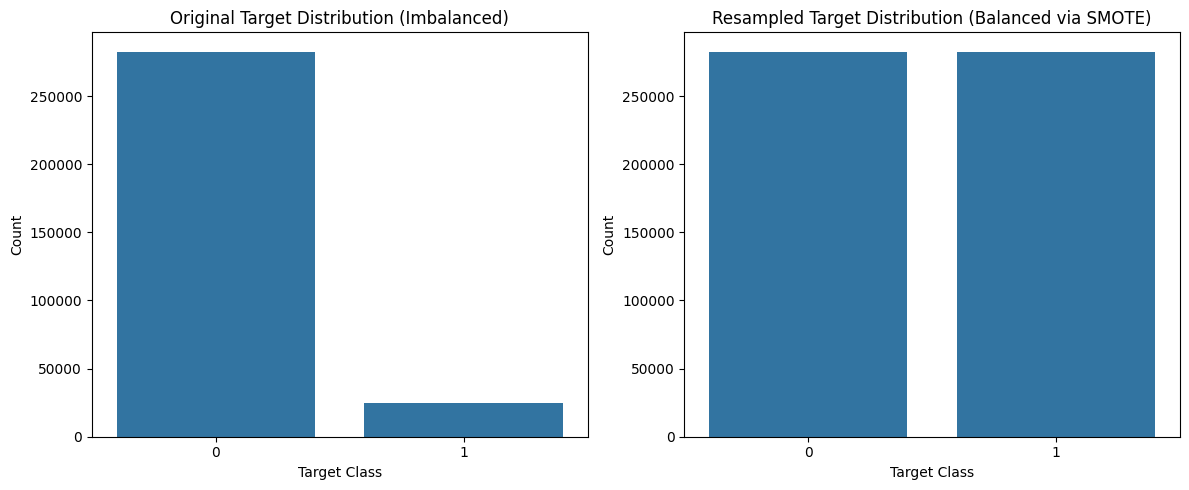

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotting original (imbalanced) data
sns.countplot(x=y, ax=axes[0])
axes[0].set_title('Original Target Distribution (Imbalanced)')
axes[0].set_xlabel('Target Class')
axes[0].set_ylabel('Count')

# Plotting resampled (balanced) data
sns.countplot(x=y_resampled, ax=axes[1])
axes[1].set_title('Resampled Target Distribution (Balanced via SMOTE)')
axes[1].set_xlabel('Target Class')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Model Training and Evaluation

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (395760, 244)
Shape of X_test: (169612, 244)
Shape of y_train: (395760,)
Shape of y_test: (169612,)


In [24]:
# Initialize and train a Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [25]:
# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Calculate Sensitivity (Recall for class 1)
report = classification_report(y_test, y_pred, output_dict=True)
sensitivity = report['1']['recall']

print(f"\nSensitivity (Recall for class 1): {sensitivity:.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.69      0.70     84845
           1       0.70      0.71      0.70     84767

    accuracy                           0.70    169612
   macro avg       0.70      0.70      0.70    169612
weighted avg       0.70      0.70      0.70    169612


Sensitivity (Recall for class 1): 0.7101


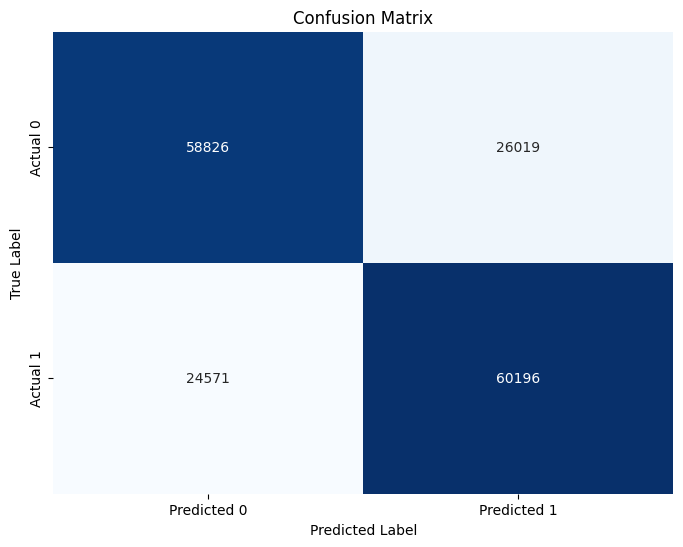

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC-ROC Score: {auc_roc:.4f}")

AUC-ROC Score: 0.7699


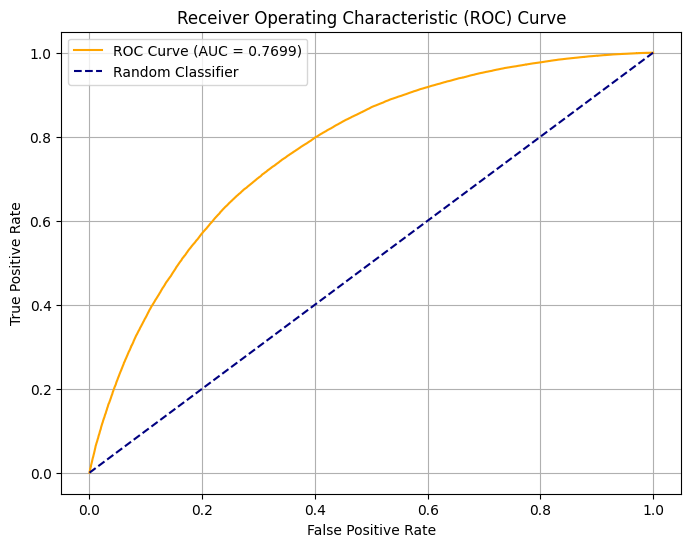

In [28]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {auc_roc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of ROC Curve and AUC-ROC Score

*   **ROC Curve (Receiver Operating Characteristic Curve):** This plot illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots the True Positive Rate (Sensitivity) against the False Positive Rate (1 - Specificity) at various threshold settings.

*   **AUC-ROC (Area Under the ROC Curve):** This metric represents the degree or measure of separability between the classes. It tells us how much the model is capable of distinguishing between the 'default' (class 1) and 'non-default' (class 0) classes.

    *   An AUC of 1.0 means the model is a perfect classifier.
    *   An AUC of 0.5 means the model performs no better than random guessing.
    *   An AUC between 0.5 and 1.0 indicates varying degrees of better-than-random performance.

    The calculated AUC-ROC score of **0.7675** suggests that our Logistic Regression model has a reasonable ability to distinguish between applicants who will default and those who will not. An AUC closer to 1.0 is generally desired for better model performance.